## Souped up depth profiles: monthly averages of one float's profiles from one year

In [1]:
import numpy as np
from oneargopy.OneArgo import Argo
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.cm as cm # new package for the colorbar
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.ticker import LogLocator, FormatStrFormatter
from matplotlib.colors import LogNorm
import gsw
from tqdm import tqdm
import matplotlib.image as mpimg
import earthaccess
import h5netcdf
import seaborn as sns
import xarray as xr
from matplotlib.patches import Rectangle
import dask
import contourpy

from importlib import reload
import SO_tools as tools; reload(tools)

/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'SO_tools' from '/Users/lilah/Documents/IBIS_Project/SO_tools.py'>

In [5]:
df_new = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data_Summer/newest_bgc_profiles_ext_alltime.csv')
# df_new = pd.read_csv('/Users/steviewalker/Documents/IBIS_Project/Data_Summer/new_bgc_profiles_BR_extended_area_all_time.csv') # for stevie

/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_38484/1697200288.py:1: DtypeWarning: Columns (0: season) have mixed types. Specify dtype option on import or set low_memory=False.
  df_new = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data_Summer/newest_bgc_profiles_ext_alltime.csv')


In [6]:
#convert to datetime
df_new['DATE'] = pd.to_datetime(df_new['DATE'],format = 'mixed')
df_new = df_new.dropna(subset=["DATE"]) #drop any cycles with no date or lat/lon 

#fix lat lon values with '--' (replace with nan) 
df_new['LATITUDE'] = pd.to_numeric(df_new['LATITUDE'], errors='coerce')
df_new['LONGITUDE'] = pd.to_numeric(df_new['LONGITUDE'], errors='coerce')

## Building function in words

subset dataframe to target year and productive season

group one floats profiles by month

average the cycles across month into one average profile per month

plot averages on one subplot for each variable (6 lines for chl-a across productive season)

variables: chl-a, temperature, salinity, nitrate, backscatter, n squared, oxygen

In [13]:
df_yr = df_new[df_new['season'] == '2019-2020']
df_yr


,Unnamed: 0.1,Unnamed: 0,WMOID,CYCLE_NUMBER,DIRECTION,DATE,DATE_QC,LATITUDE,LONGITUDE,POSITION_QC,...,DOWNWELLING_PAR_ADJUSTED_ERROR,year,month,season,SA,CT,rho,sigma0,nsq,MLP
89464,89464,90444,3902129,59,A,2019-09-09 12:06:40+00:00,1,-64.045816,168.641973,8,...,NaN,2019,9,2019-2020,34.534884,-1.629937,1028.210561,27.668598,8.694747e-07,122.50
89465,89465,90445,3902129,59,A,2019-09-09 12:06:40+00:00,1,-64.045816,168.641973,8,...,NaN,2019,9,2019-2020,34.534889,-1.629944,1028.212007,27.668601,8.702839e-07,122.50
89466,89466,90446,3902129,59,A,2019-09-09 12:06:40+00:00,1,-64.045816,168.641973,8,...,NaN,2019,9,2019-2020,34.567031,-1.415451,1028.252469,27.687791,7.744389e-07,122.50
89467,89467,90447,3902129,59,A,2019-09-09 12:06:40+00:00,1,-64.045816,168.641973,8,...,NaN,2019,9,2019-2020,34.569128,-1.401463,1028.255082,27.689018,7.753388e-07,122.50
89468,89468,90448,3902129,59,A,2019-09-09 12:06:40+00:00,1,-64.045816,168.641973,8,...,NaN,2019,9,2019-2020,34.689157,-0.334935,1028.326445,27.742037,-2.577808e-07,122.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1512884,1512884,1513864,6903768,12,A,2020-04-30 05:39:30+00:00,1,-59.031293,171.853648,1,...,NaN,2020,4,2019-2020,34.897882,1.952284,1036.689008,27.762748,2.225350e+03,0.07
1512885,1512885,1513865,6903768,12,A,2020-04-30 05:39:30+00:00,1,-59.031293,171.853648,1,...,NaN,2020,4,2019-2020,34.898911,1.933601,1036.804777,27.765043,2.237850e+03,0.07
1512886,1512886,1513866,6903768,12,A,2020-04-30 05:39:30+00:00,1,-59.031293,171.853648,1,...,NaN,2020,4,2019-2020,34.898918,1.933429,1036.805841,27.765062,2.250250e+03,0.07
1512887,1512887,1513867,6903768,12,A,2020-04-30 05:39:30+00:00,1,-59.031293,171.853648,1,...,NaN,2020,4,2019-2020,34.900939,1.905951,1036.923966,27.768835,2.262650e+03,0.07


In [8]:
cond1 = (df_yr['month'] >= 11)
cond2 = (df_yr['month'] <= 4)

df_m = df_yr[cond1 | cond2]
df_m

,Unnamed: 0.1,Unnamed: 0,WMOID,CYCLE_NUMBER,DIRECTION,DATE,DATE_QC,LATITUDE,LONGITUDE,POSITION_QC,...,DOWNWELLING_PAR_ADJUSTED_ERROR,year,month,season,SA,CT,rho,sigma0,nsq,MLP
92152,92152,93132,3902129,65,A,2019-11-08 12:11:40+00:00,1,-64.470461,170.490842,8,...,NaN,2019,11,2019-2020,34.737000,0.060552,1028.321227,27.760205,3.415226e-07,162.80
92153,92153,93133,3902129,65,A,2019-11-08 12:11:40+00:00,1,-64.470461,170.490842,8,...,NaN,2019,11,2019-2020,34.737004,0.060541,1028.322657,27.760209,3.420375e-07,162.80
92154,92154,93134,3902129,65,A,2019-11-08 12:11:40+00:00,1,-64.470461,170.490842,8,...,NaN,2019,11,2019-2020,34.741782,0.114628,1028.344730,27.761105,2.180903e-08,162.80
92155,92155,93135,3902129,65,A,2019-11-08 12:11:40+00:00,1,-64.470461,170.490842,8,...,NaN,2019,11,2019-2020,34.742098,0.118234,1028.346198,27.761161,-3.018154e-08,162.80
92156,92156,93136,3902129,65,A,2019-11-08 12:11:40+00:00,1,-64.470461,170.490842,8,...,NaN,2019,11,2019-2020,34.750641,0.166683,1028.371559,27.765345,1.357937e-06,162.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1512884,1512884,1513864,6903768,12,A,2020-04-30 05:39:30+00:00,1,-59.031293,171.853648,1,...,NaN,2020,4,2019-2020,34.897882,1.952284,1036.689008,27.762748,2.225350e+03,0.07
1512885,1512885,1513865,6903768,12,A,2020-04-30 05:39:30+00:00,1,-59.031293,171.853648,1,...,NaN,2020,4,2019-2020,34.898911,1.933601,1036.804777,27.765043,2.237850e+03,0.07
1512886,1512886,1513866,6903768,12,A,2020-04-30 05:39:30+00:00,1,-59.031293,171.853648,1,...,NaN,2020,4,2019-2020,34.898918,1.933429,1036.805841,27.765062,2.250250e+03,0.07
1512887,1512887,1513867,6903768,12,A,2020-04-30 05:39:30+00:00,1,-59.031293,171.853648,1,...,NaN,2020,4,2019-2020,34.900939,1.905951,1036.923966,27.768835,2.262650e+03,0.07


In [10]:
df_m['month'].unique()

array([11, 12,  1,  2,  3,  4])

In [18]:
nov = df_m[df_m['month'] == 11]
nov

,Unnamed: 0.1,Unnamed: 0,WMOID,CYCLE_NUMBER,DIRECTION,DATE,DATE_QC,LATITUDE,LONGITUDE,POSITION_QC,...,DOWNWELLING_PAR_ADJUSTED_ERROR,year,month,season,SA,CT,rho,sigma0,nsq,MLP
92152,92152,93132,3902129,65,A,2019-11-08 12:11:40+00:00,1,-64.470461,170.490842,8,...,NaN,2019,11,2019-2020,34.737000,0.060552,1028.321227,27.760205,3.415226e-07,162.80
92153,92153,93133,3902129,65,A,2019-11-08 12:11:40+00:00,1,-64.470461,170.490842,8,...,NaN,2019,11,2019-2020,34.737004,0.060541,1028.322657,27.760209,3.420375e-07,162.80
92154,92154,93134,3902129,65,A,2019-11-08 12:11:40+00:00,1,-64.470461,170.490842,8,...,NaN,2019,11,2019-2020,34.741782,0.114628,1028.344730,27.761105,2.180903e-08,162.80
92155,92155,93135,3902129,65,A,2019-11-08 12:11:40+00:00,1,-64.470461,170.490842,8,...,NaN,2019,11,2019-2020,34.742098,0.118234,1028.346198,27.761161,-3.018154e-08,162.80
92156,92156,93136,3902129,65,A,2019-11-08 12:11:40+00:00,1,-64.470461,170.490842,8,...,NaN,2019,11,2019-2020,34.750641,0.166683,1028.371559,27.765345,1.357937e-06,162.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
925531,925531,926511,5905379,67,A,2019-11-28 10:55:38.001153+00:00,1,-64.877084,167.516103,8,...,NaN,2019,11,2019-2020,NaN,NaN,NaN,NaN,NaN,4.79
925532,925532,926512,5905379,67,A,2019-11-28 10:55:38.001153+00:00,1,-64.877084,167.516103,8,...,NaN,2019,11,2019-2020,NaN,NaN,NaN,NaN,NaN,4.79
925533,925533,926513,5905379,67,A,2019-11-28 10:55:38.001153+00:00,1,-64.877084,167.516103,8,...,NaN,2019,11,2019-2020,NaN,NaN,NaN,NaN,NaN,4.79
925534,925534,926514,5905379,67,A,2019-11-28 10:55:38.001153+00:00,1,-64.877084,167.516103,8,...,NaN,2019,11,2019-2020,NaN,NaN,NaN,NaN,NaN,4.79


In [19]:
nov['CHLA_ADJUSTED'].mean

<bound method Series.mean of 92152          NaN
92153          NaN
92154          NaN
92155          NaN
92156          NaN
            ...   
925531    0.000000
925532   -0.001407
925533    0.000000
925534    0.000000
925535    0.000000
Name: CHLA_ADJUSTED, Length: 11326, dtype: float64>

## Function

ValueError: x and y must have same first dimension, but have shapes (1,) and (64931,)

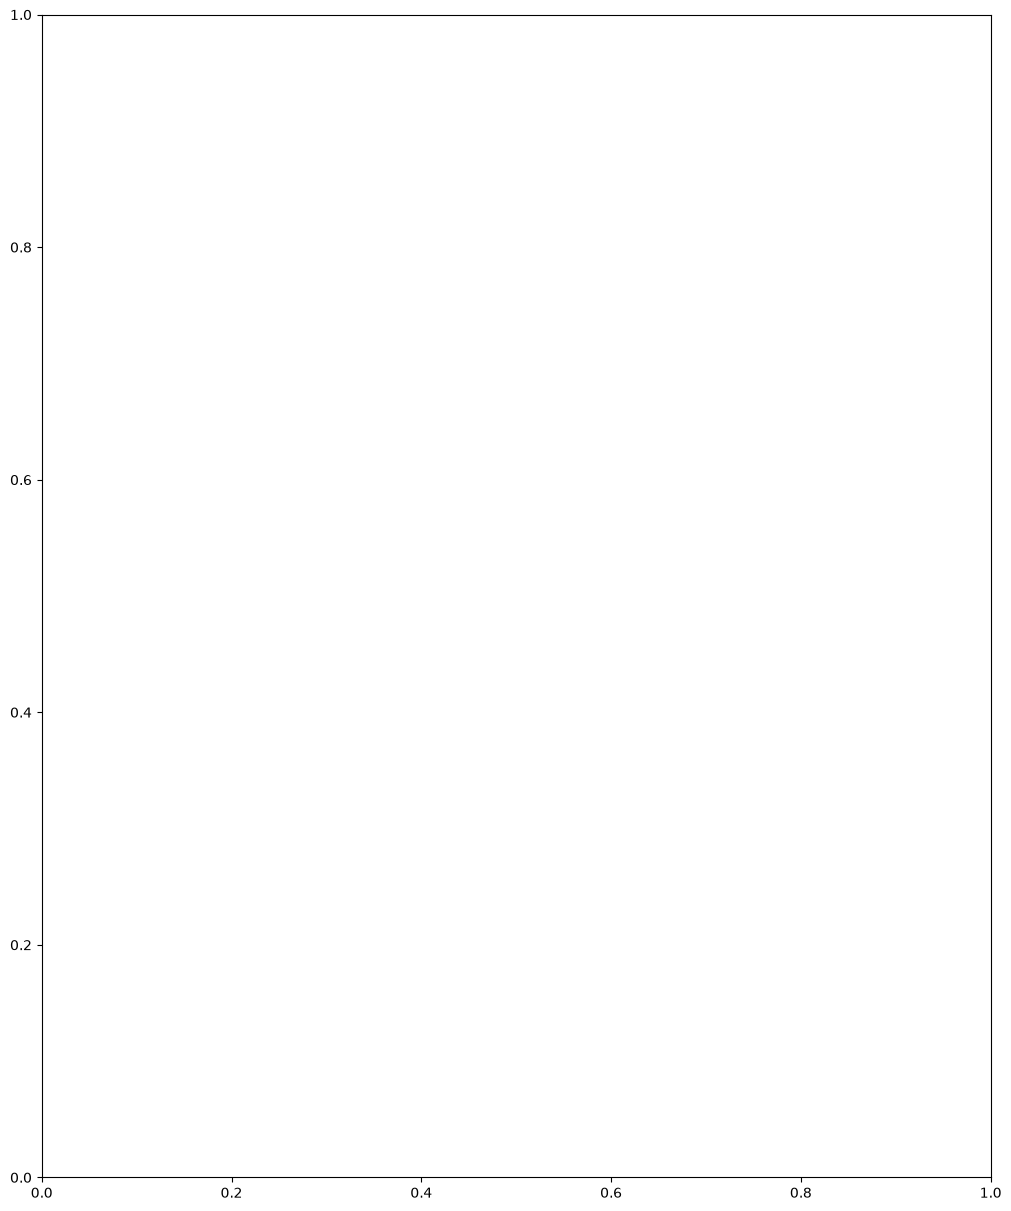

In [21]:
def average_depth_prof(df):

    # subsetting to target year and productive season
    df_yr = df[df['season'] == '2019-2020']
    cond1 = (df_yr['month'] >= 11)
    cond2 = (df_yr['month'] <= 4)
    df_m = df_yr[cond1 | cond2]

    # averaging across months

    nov = df_m[df_m['month'] == 11]
    nov_m = nov['CHLA_ADJUSTED'].mean

    fig = plt.figure(figsize=(10,12), layout='constrained')
    ax = fig.add_subplot()
    plot = ax.plot(nov_m, df_m['PRES_ADJUSTED'])

    ax.set_ylim(0,200)
    ax.invert_yaxis()
    # ax.set_title(title, fontsize=title_size)

average_depth_prof(df=df_new)